In [1]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd

import csv
import gzip

import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context
import anndata
import torch

# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7, # figure.titlesize,
    'legend.title_fontsize' : 5
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}

import helper_functions



/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# --- INIT ---



# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided' # 'transformed_X_outlier_variance'
cluster_resolution = 0.05
subcluster_resolution = 0.20


# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder

# clusters
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)

# SMC clusters
subclustering_folder = '%s/subclustering/res_%s' % (clustering_folder,subcluster_resolution)
subcluster_df_fileout = '%s/smc_subclusters.tsv' % (subclustering_folder)


# settings
mesor_frac_thresh = 0.9
mesor_effect_thresh = 0.3 / np.log10(np.e)
amp_frac_thresh = 0.9
amp_effect_thresh = 0.2 / np.log10(np.e)
acrophase_frac_thresh = 0.1
acrophase_effect_thresh = 3 * (np.pi / 12.0)
frac_circadian_samples_crossing_zero_thresh = 0.1
log10_bf_thresh = 2
num_waveform_samples = 300
use_log_prop_fft = True
frac_cell_detected_thresh = 0.1
use_subclusters = False

# folder out
folder_out = '%s/Dropbox/aorta_circadian_data/results/fig_4_male_aligned_vs_male_misaligned' % head_folder
if use_subclusters:
    folder_out = '%s/smc_subclusters' % folder_out
if not os.path.exists(folder_out):
    os.makedirs(folder_out)


# set the cluster column
if use_subclusters:
    clustering_folder = subclustering_folder
    cluster_df_fileout = subcluster_df_fileout



In [3]:
# --- LOAD THE ADATA ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [4]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')
subcluster_df = pd.read_table(subcluster_df_fileout,sep='\t',index_col='index')


# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]
subcluster_df = subcluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
if use_subclusters:
    adata.obs["cluster"] = np.array(cluster_df['smc_subcluster'])
else:
    adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])
adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [5]:
# --- GET UNIQUE DESCRIPTOINS / CELL TYPES AND SET THE CLUSTER - CELL_TYPE DICT ---

# ** get the unique descriptions **
descriptions = list(adata.obs['description'].unique())

# ** get the unique clusters **
clusters = sorted(list(adata.obs['cluster'].unique()))
clusters = list(filter(lambda x: ~np.isnan(x),clusters)) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(map(lambda x: int(x),clusters))
clusters = sorted(clusters)


# ** get the cluster cell type dict **
if use_subclusters:
    smc_subcluster_cell_type_names = list(map(lambda x: "SMC%s" % int(x), clusters))
    cluster_cell_type_dict = dict(zip(clusters,
                                      smc_subcluster_cell_type_names))
else:
    cluster_cell_type_dict = dict(zip(sorted(list(adata.obs['cluster'].unique())),
                                      ['SMC','Fibroblast','Endothelial', 'Macrophage', 'Erythrocyte', 'T', 'Oligodendrocyte', 'Endothelial2', 'Neuron']))


    


In [6]:
# --- LIMIT CLUSTERS ---

if use_subclusters:
    clusters = [0,1,2,3,4,5]
else:
    clusters = [0,1,2,3]
    
clusters
    

[0, 1, 2, 3]

In [7]:
# --- MAKE THE FOLDER OUTS ---

# head folder
reg_head_folder = '%s/nonparametric_reg' % clustering_folder


# subfolders for each cluster / condition combo
cluster_description_folder_out_dict = {}
for cluster in clusters:
    cluster_reg_folder = '%s/cluster_%s' % (reg_head_folder,cluster)
    for description in descriptions:
        cluster_description_reg_folder = '%s/%s' % (cluster_reg_folder,description)

        # update dict
        if cluster not in cluster_description_folder_out_dict:
            cluster_description_folder_out_dict[cluster] = {}
        cluster_description_folder_out_dict[cluster][description] = cluster_description_reg_folder

    
    

In [8]:
# --- LOAD THE GENES TO ESTIMATE ---

genes_to_est_fileout = '%s/genes_to_est.txt' % reg_head_folder
with open(genes_to_est_fileout) as file_obj:
    reg_genes_to_est = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))
    
    
len(reg_genes_to_est)




22193

In [20]:
# --- SET THE CONDITION TUPLES ---

condit_tuples = [['male', 'aligned', 'control'],
['female', 'aligned', 'control'],
['male', 'misaligned', 'control'],
['female', 'misaligned', 'control'],
['male', 'aligned', 'ko'],
['female', 'aligned', 'ko']]




In [133]:
# --- SET THE CLUSTER ----


cluster = 2


In [134]:
# # --- SET THE CONDITIONS WE WANT TO COMPARE ---

# condit_1 = 'male aligned bmal1-control'
# condit_2 = 'male misaligned bmal1-control'
# condit_1_label = 'Aligned'
# condit_2_label = 'Misaligned'
# dif_label = 'Alignment'




In [135]:
# --- LOAD THE PARAMS ---


# init param dict
param_df_dict = {}

# fill
for sex, alignment, bmal in condit_tuples:
    
    # init sub-dicts
    if sex not in param_df_dict:
        param_df_dict[sex] = {}
    if alignment not in param_df_dict[sex]:
        param_df_dict[sex][alignment] = {}
    
    # get condit string
    condit = '%s %s bmal1-%s' % (sex, alignment,bmal)

    # get param df's
    gene_log_alpha_df_1, gene_log_beta_df_1, gene_log_min_max_df_1, gene_stat_df_1 = helper_functions.load_param_dfs_from_path(cluster_description_folder_out_dict[cluster][condit])
    param_df_dict[sex][alignment][bmal] = {
        "log_alpha_df" : gene_log_alpha_df_1,
        'log_beta_df' : gene_log_beta_df_1,
        'log_min_max_df' : gene_log_min_max_df_1,
        'gene_stat_df' : gene_stat_df_1
    }
    
    print(sex,alignment,bmal)

    






male aligned control
female aligned control
male misaligned control
female misaligned control
male aligned ko
female aligned ko


In [136]:
# --- FILTER GENES BASED ON DETECTED FRACTION ---


# set frac detected thresh
frac_cell_detected_thresh = 0.1

# clock and ubiq genes
clock_and_ubiq_path = '%s/Desktop/tempo/data/core_clock_and_ubiq_genes.txt' % head_folder
clock_and_ubiq_genes = np.array(pd.read_table(clock_and_ubiq_path,header=None).iloc[:,0])

# hemoglobin genes
hemoglobin_genes = list(filter(lambda x: x[:2] == 'Hb' and '-' in x, adata.var_names))

# genes to filter
genes_to_filter = set()
print("Using the union of genes to filter over the conditions.\nNeed to implement intersection too.")
for sex, alignment, bmal in condit_tuples:
    gene_stat_df = param_df_dict[sex][alignment][bmal]['gene_stat_df']
    these_genes_to_filter = list(gene_stat_df[np.array(gene_stat_df['frac_cell_detected'] < frac_cell_detected_thresh) & np.array(~np.isin(gene_stat_df.index,clock_and_ubiq_genes))].index)
    genes_to_filter.update(set(these_genes_to_filter))
genes_to_filter = list(set(genes_to_filter).union(set(hemoglobin_genes)))
print("%s genes filtered" % len(genes_to_filter))


# get common genes
common_genes = set()
df_num = 0
for sex, alignment, bmal in condit_tuples:
    gene_stat_df = param_df_dict[sex][alignment][bmal]['gene_stat_df']
    if df_num == 0:
        common_genes = set(gene_stat_df.index)
    else:
        common_genes = common_genes.intersection(set(gene_stat_df.index))
    df_num += 1
common_genes = list(common_genes.difference(set(genes_to_filter)))
print("%s common genes to compare" % len(common_genes))


# filter
for sex, alignment, bmal in condit_tuples:
    for df in param_df_dict[sex][alignment][bmal]:
        param_df_dict[sex][alignment][bmal][df] = param_df_dict[sex][alignment][bmal][df].loc[common_genes]


            
            


Using the union of genes to filter over the conditions.
Need to implement intersection too.
11594 genes filtered
6860 common genes to compare


In [139]:
param_df_dict['female']['aligned']['ko']['gene_stat_df'].loc[['Ddit4']]



,frac_real_circadian_samples_crossing_zero,frac_imag_circadian_samples_crossing_zero,frac_circadian_samples_crossing_zero,frac_circadian_samples_largest_component,frac_circadian_samples_largest_component_p_val,waveform_log_evidence,flat_waveform_log_evidence,non_circadian_component_subtracted_waveform_log_evidence,circadian_component_subtracted_waveform_log_evidence,circ_bf_frac,waveform_over_circadian_component_subtracted_log10_bf,expected_mesor,expected_acrophase,frac_cell_detected,num_cell_detected
gene,,,,,,,,,,,,,,,
Ddit4,0.18,0.24,0.18,0.68,0.96,-1285.5535,-1283.9547,-1279.949,-1293.4628,0.0,3.434966,-9.040037,2.586438,0.475,418


In [140]:
param_df_dict['female']['aligned']['control']['gene_stat_df'].loc[['Ddit4']]



,frac_real_circadian_samples_crossing_zero,frac_imag_circadian_samples_crossing_zero,frac_circadian_samples_crossing_zero,frac_circadian_samples_largest_component,frac_circadian_samples_largest_component_p_val,waveform_log_evidence,flat_waveform_log_evidence,non_circadian_component_subtracted_waveform_log_evidence,circadian_component_subtracted_waveform_log_evidence,circ_bf_frac,waveform_over_circadian_component_subtracted_log10_bf,expected_mesor,expected_acrophase,frac_cell_detected,num_cell_detected
gene,,,,,,,,,,,,,,,
Ddit4,0.16,0.4,0.16,0.23,1.0,-783.36865,-812.56165,-818.7335,-775.0929,0.0,-3.594116,-9.73158,2.843154,0.430272,253


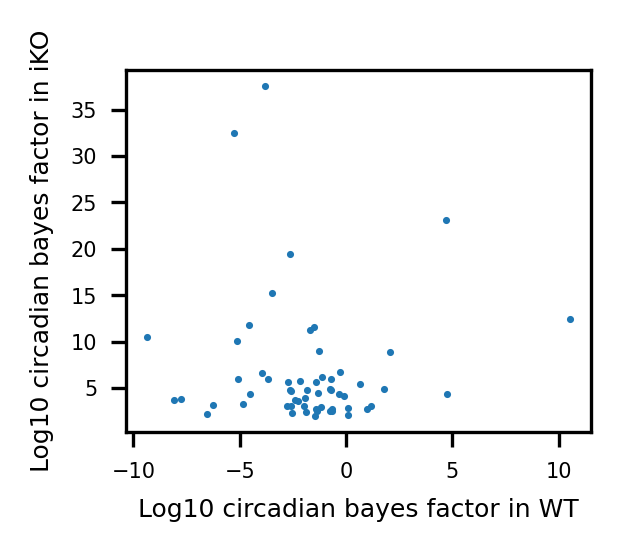

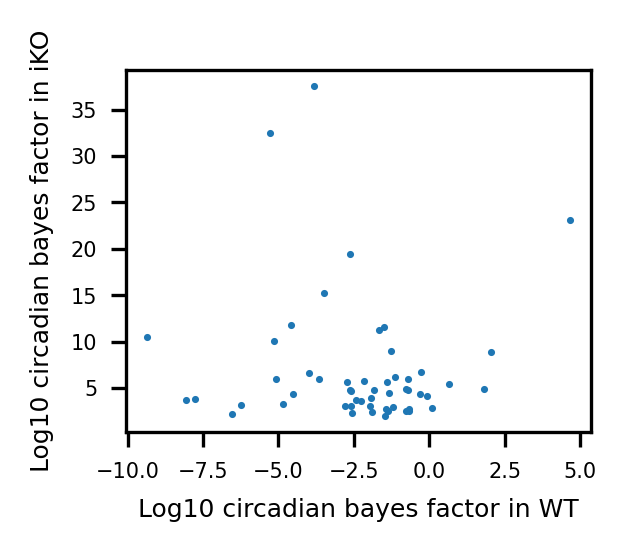

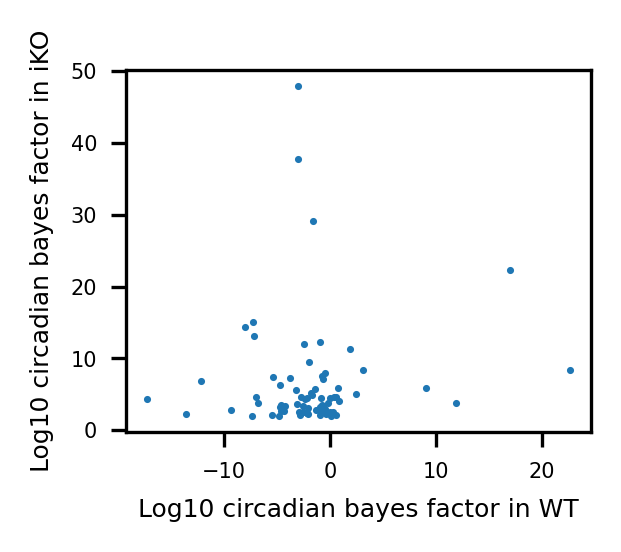

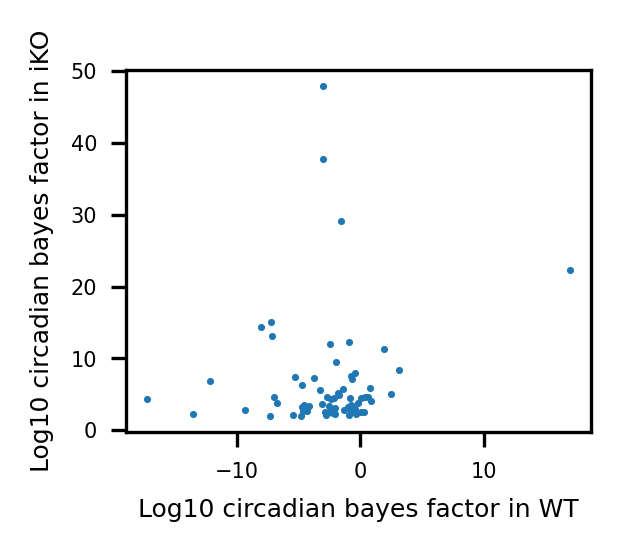

In [117]:
# --- COMPARE THE BAYES FACTORS BETWEEN THE KO CYCLERS AND IN ALIGNMENT ---


for sex in ['male','female']:
    
    # get KO cyclers
    ko_cyclers = param_df_dict[sex]['aligned']['ko']['gene_stat_df'][param_df_dict[sex]['aligned']['ko']['gene_stat_df']['waveform_over_circadian_component_subtracted_log10_bf'] >= log10_bf_thresh].index
    ko_cyclers = list(ko_cyclers)
    
    # WT cyclers
    wt_cyclers = param_df_dict[sex]['aligned']['control']['gene_stat_df'][param_df_dict[sex]['aligned']['control']['gene_stat_df']['waveform_over_circadian_component_subtracted_log10_bf'] >= log10_bf_thresh].index
    wt_cyclers = list(wt_cyclers)
    
    # get the BF
    bf_in_ko = np.array(param_df_dict[sex]['aligned']['ko']['gene_stat_df'].loc[ko_cyclers]['waveform_over_circadian_component_subtracted_log10_bf'])
    bf_in_wt = np.array(param_df_dict[sex]['aligned']['control']['gene_stat_df'].loc[ko_cyclers]['waveform_over_circadian_component_subtracted_log10_bf'])
    
    # look at the bayes factors in both
    fig,ax=plt.subplots(figsize=(2,1.6),dpi=300)
    plt.scatter(bf_in_wt,bf_in_ko,s=0.5)
    plt.xlabel("Log10 circadian bayes factor in WT")
    plt.ylabel("Log10 circadian bayes factor in iKO")
    plt.show()
    
    
    # run enrichment on shared cyclers
    shared_cyclers = list(set(wt_cyclers).intersection(set(ko_cyclers)))
    unique_ko_cyclers = list(set(ko_cyclers).difference(set(wt_cyclers)))

    # get the genes gaining cycling in KO
    bf_in_ko = np.array(param_df_dict[sex]['aligned']['ko']['gene_stat_df']['waveform_over_circadian_component_subtracted_log10_bf'])
    bf_in_wt = np.array(param_df_dict[sex]['aligned']['control']['gene_stat_df']['waveform_over_circadian_component_subtracted_log10_bf'])
    gained_cycling_ko_genes = list(param_df_dict[sex]['aligned']['ko']['gene_stat_df'][(bf_in_ko - bf_in_wt >= 2) & (bf_in_ko >= 2)].index)

    # look at the bayes factors for genes gaining cycling in both
    bf_in_ko = np.array(param_df_dict[sex]['aligned']['ko']['gene_stat_df'].loc[gained_cycling_ko_genes]['waveform_over_circadian_component_subtracted_log10_bf'])
    bf_in_wt = np.array(param_df_dict[sex]['aligned']['control']['gene_stat_df'].loc[gained_cycling_ko_genes]['waveform_over_circadian_component_subtracted_log10_bf'])
    
    fig,ax=plt.subplots(figsize=(2,1.6),dpi=300)
    plt.scatter(bf_in_wt,bf_in_ko,s=0.5)
    plt.xlabel("Log10 circadian bayes factor in WT")
    plt.ylabel("Log10 circadian bayes factor in iKO")
    plt.show()
    
    # write out the genes
    subfolder_out = '%s/dropbox/aorta_circadian_data/results/ko_unique_cyclers/cluster_%s/%s' % (head_folder,cluster,sex)
    if not os.path.exists(subfolder_out):
        os.makedirs(subfolder_out)
    gained_cycling_df = pd.DataFrame()
    gained_cycling_df['gene'] = gained_cycling_ko_genes
    bf_in_ko = np.array(param_df_dict[sex]['aligned']['ko']['gene_stat_df'].loc[gained_cycling_ko_genes]['waveform_over_circadian_component_subtracted_log10_bf'])
    bf_in_wt = np.array(param_df_dict[sex]['aligned']['control']['gene_stat_df'].loc[gained_cycling_ko_genes]['waveform_over_circadian_component_subtracted_log10_bf'])
    gained_cycling_df['bf_in_wt'] = bf_in_wt
    gained_cycling_df['log10_bf_in_ko'] = bf_in_ko
    gained_cycling_df['dif'] = bf_in_ko - bf_in_wt
    gained_cycling_df = gained_cycling_df.set_index('gene')
    fileout = "%s/gained_cycling.tsv" % (subfolder_out)
    gained_cycling_df.to_csv(fileout,sep='\t')
    
    
    # write out the common
    common_cycling_df = pd.DataFrame()
    common_cycling_df['gene'] = shared_cyclers
    bf_in_ko = np.array(param_df_dict[sex]['aligned']['ko']['gene_stat_df'].loc[shared_cyclers]['waveform_over_circadian_component_subtracted_log10_bf'])
    bf_in_wt = np.array(param_df_dict[sex]['aligned']['control']['gene_stat_df'].loc[shared_cyclers]['waveform_over_circadian_component_subtracted_log10_bf'])
    common_cycling_df['bf_in_wt'] = bf_in_wt
    common_cycling_df['log10_bf_in_ko'] = bf_in_ko
    common_cycling_df['dif'] = bf_in_ko - bf_in_wt
    common_cycling_df = common_cycling_df.set_index('gene')
    fileout = "%s/common_cycling.tsv" % (subfolder_out)
    common_cycling_df.to_csv(fileout,sep='\t')
    
    
    
    # run enrichment for gained cyclers
    import gseapy
    import warnings
    warnings.filterwarnings("ignore")
    res = gseapy.enrichr(gene_list=list(gained_cycling_ko_genes),
                         gene_sets = 'KEGG_2019_Mouse',
                        organism = 'mouse',
                        background = reg_genes_to_est,
                        cutoff=1.0)
    res_df = res.results
    res_df = res_df.set_index("Term")
    res_df['Genes'] = list(map(lambda y: ";".join(list(map(lambda x: x.lower().capitalize(), y.split(";")))), list(res_df['Genes'])))
    fileout = "%s/gained_cycling_enrichment.tsv" % (subfolder_out)
    res_df.to_csv(fileout,sep='\t')
    
    
    # run enrichment for common cyclers
    res = gseapy.enrichr(gene_list=list(shared_cyclers),
                         gene_sets = 'KEGG_2019_Mouse',
                        organism = 'mouse',
                        background = reg_genes_to_est,
                        cutoff=1.0)
    res_df = res.results
    res_df = res_df.set_index("Term")
    res_df['Genes'] = list(map(lambda y: ";".join(list(map(lambda x: x.lower().capitalize(), y.split(";")))), list(res_df['Genes'])))
    fileout = "%s/common_cycling_enrichment.tsv" % (subfolder_out)
    res_df.to_csv(fileout,sep='\t')
    
    



